Shape: (44096, 22)


Columns:
['sample_id', 'image_filename', 'image_path', 'segm_path', 'caption_text', 'gender', 'category', 'item_id', 'look_id', 'view_code', 'view_name', 'shape_labels', 'fabric_labels', 'pattern_labels', 'keypoints_raw', 'exists_image', 'exists_segm', 'exists_caption', 'exists_labels', 'exists_keypoints', 'processed_image_path', 'masked_image_path']

Missing values:
sample_id                   0
image_filename              0
image_path                  0
segm_path               31395
caption_text             1559
gender                      0
category                    0
item_id                     0
look_id                     0
view_code                   0
view_name                   0
shape_labels             1552
fabric_labels               0
pattern_labels              0
keypoints_raw           31394
exists_image                0
exists_segm                 0
exists_caption              0
exists_labels               0
exists_keypoints            0
processed

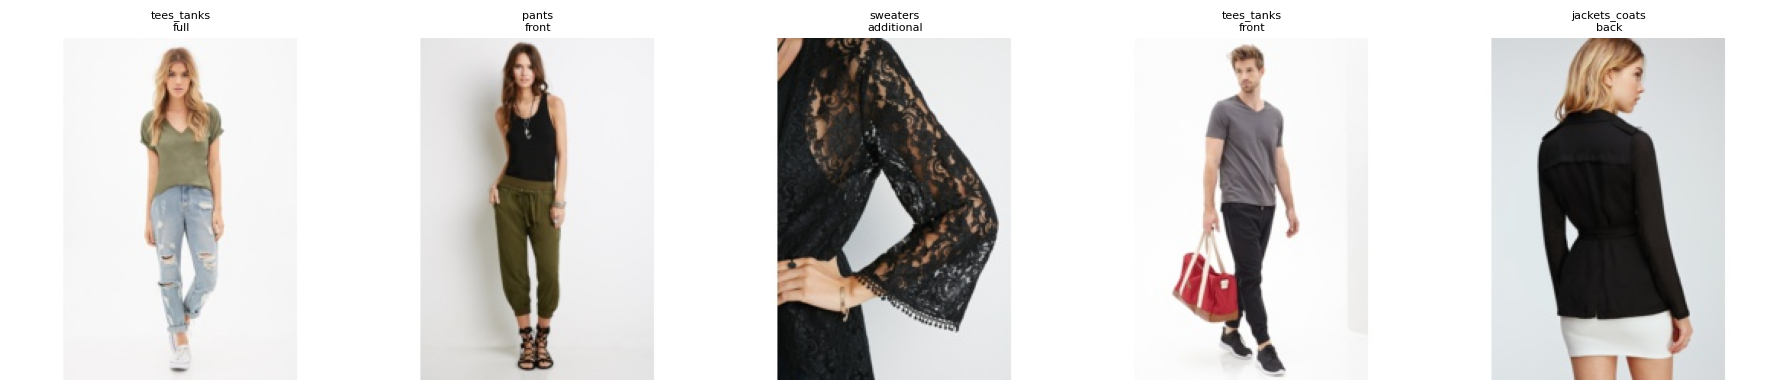

In [1]:
#data building verification 

import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt

# load final metadata
df = pd.read_csv("outputs/metadata/preprocessed_metadata.csv")

print("Shape:", df.shape)
print ("\n")
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

# check processed image paths
df["path_exists"] = df["processed_image_path"].apply(lambda x: os.path.exists(x) if pd.notna(x) else False)
print("\nProcessed image path exists:")
print(df["path_exists"].value_counts())

# show a few random rows
print("\nSample rows:")
print(df.sample(5)[["sample_id", "category", "view_name", "processed_image_path"]])

# display 5 random processed images
sample = df[df["path_exists"]].sample(5)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (_, row) in zip(axes, sample.iterrows()):
    img = Image.open(row["processed_image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f'{row["category"]}\n{row["view_name"]}', fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [2]:
#Load EfficientNet and extract embeddings 
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras import Input


# Keep only rows with valid processed image paths
df = df[df["processed_image_path"].notna()].copy()
df = df[df["processed_image_path"].apply(os.path.exists)].copy()
df.reset_index(drop=True, inplace=True)

print("Usable rows:", len(df))

# Build feature extractor
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))
x = GlobalAveragePooling2D()(base_model.output)
model = Model(inputs=base_model.input, outputs=x)

def extract_embedding(img_path):
    img = keras_image.load_img(img_path, target_size=(224, 224))
    x = keras_image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    emb = model.predict(x, verbose=0)
    return emb.flatten()

embeddings = []
valid_paths = []

image_paths = df["masked_image_path"].fillna(df["processed_image_path"])

for img_path in tqdm(image_paths):
    try:
        emb = extract_embedding(img_path)
        embeddings.append(emb)
        valid_paths.append(img_path)
    except Exception as e:
        print(f"Error with {img_path}: {e}")

embeddings = np.array(embeddings)

print("Embeddings shape:", embeddings.shape)

# Save outputs
np.save("outputs/metadata/image_embeddings.npy", embeddings)
df = df.iloc[:len(valid_paths)].copy()
df["embedding_index"] = range(len(df))
df.to_csv("outputs/metadata/embedding_metadata.csv", index=False)

print("Saved embeddings and metadata.")


Usable rows: 44096


100%|██████████| 44096/44096 [42:15<00:00, 17.39it/s]  


Embeddings shape: (44096, 1280)
Saved embeddings and metadata.


In [3]:
os.makedirs("outputs/metadata", exist_ok=True)

In [5]:
os.path.exists("outputs/metadata/image_embeddings.npy")
os.path.exists("outputs/metadata/embedding_metadata.csv")

True

In [6]:
import numpy as np
import pandas as pd

emb = np.load("outputs/metadata/image_embeddings.npy")
meta = pd.read_csv("outputs/metadata/embedding_metadata.csv")

print(emb.shape)
print(meta.shape)
print(np.isnan(emb).sum())
print(np.isinf(emb).sum())
print(np.linalg.norm(emb, axis=1)[:10])

(44096, 1280)
(44096, 24)
0
0
[ 9.481909  9.334972 10.86161   9.695876 10.8953   10.563702 10.834114
 10.542496  9.879093 11.006503]


In [13]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def get_similar(idx, embeddings, top_k=6):
    # Ensure embeddings is a numpy array
    embeddings = np.array(embeddings)

    # Check index validity
    if idx >= len(embeddings):
        raise IndexError("Index out of range")

    # Reshape query vector properly
    query = embeddings[idx].reshape(1, -1)

    # Compute cosine similarity
    sims = cosine_similarity(query, embeddings)[0]

    # Sort in descending order
    order = np.argsort(sims)[::-1]

    # Remove the same image
    order = order[order != idx]

    # Take top_k
    top_indices = order[:top_k]
    top_scores = sims[top_indices]

    return top_indices, top_scores

In [15]:
print(meta.columns.tolist())

['sample_id', 'image_filename', 'image_path', 'segm_path', 'caption_text', 'gender', 'category', 'item_id', 'look_id', 'view_code', 'view_name', 'shape_labels', 'fabric_labels', 'pattern_labels', 'keypoints_raw', 'exists_image', 'exists_segm', 'exists_caption', 'exists_labels', 'exists_keypoints', 'processed_image_path', 'masked_image_path', 'path_exists', 'embedding_index']


In [16]:
def get_neighbors_same_category(query_idx, meta, emb, top_k=5):
    query_cat = meta.iloc[query_idx]["category"]

    # all rows with same category
    idxs = meta[meta["category"] == query_cat].index.to_numpy()

    # similarity between query and only same-category items
    query_vec = emb[query_idx].reshape(1, -1)
    sims = cosine_similarity(query_vec, emb[idxs])[0]

    # descending order
    order = np.argsort(sims)[::-1]

    # remove self safely
    idxs_ordered = idxs[order]
    idxs_ordered = idxs_ordered[idxs_ordered != query_idx]

    return idxs_ordered[:top_k]

In [21]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def show_neighbors(query_idx, meta, embeddings, image_col="processed_image_path", top_k=5):
    
    # use correct function
    neighbors, scores = get_similar(query_idx, embeddings, top_k=top_k)

    plt.figure(figsize=(3 * (top_k + 1), 5))

    # ---- Query image ----
    query_path = meta.iloc[query_idx][image_col]

    if not os.path.exists(query_path):
        print(f"Query image not found: {query_path}")
        return

    query_img = Image.open(query_path).convert("RGB")

    plt.subplot(1, top_k + 1, 1)
    plt.imshow(query_img)
    plt.title(f"Query\n{meta.iloc[query_idx]['category']}")
    plt.axis("off")

    # ---- Neighbor images ----
    for i, (nbr_idx, score) in enumerate(zip(neighbors, scores), start=2):
        nbr_path = meta.iloc[nbr_idx][image_col]

        if not os.path.exists(nbr_path):
            print(f"Missing image: {nbr_path}")
            continue

        try:
            nbr_img = Image.open(nbr_path).convert("RGB")

            plt.subplot(1, top_k + 1, i)
            plt.imshow(nbr_img)
            plt.title(f"{meta.iloc[nbr_idx]['category']}\n{score:.3f}")
            plt.axis("off")

        except Exception as e:
            print(f"Error loading {nbr_path}: {e}")

    plt.tight_layout()
    plt.show()

In [22]:
print(sorted(meta["category"].dropna().unique())[:50])
print("Total categories:", meta["category"].nunique())

['blouses_shirts', 'cardigans', 'denim', 'dresses', 'graphic_tees', 'jackets_coats', 'jackets_vests', 'leggings', 'pants', 'rompers_jumpsuits', 'shirts_polos', 'shorts', 'skirts', 'suiting', 'sweaters', 'sweatshirts_hoodies', 'tees_tanks']
Total categories: 17


In [23]:
tee_idx = meta[meta["category"].str.contains("Tees", case=False, na=False)].index[0]
dress_idx = meta[meta["category"].str.contains("Dress", case=False, na=False)].index[0]
denim_idx = meta[meta["category"].str.contains("Denim", case=False, na=False)].index[0]
jacket_idx = meta[meta["category"].str.contains("Jacket", case=False, na=False)].index[0]

print(tee_idx, dress_idx, denim_idx, jacket_idx)

2885 14741 0 97


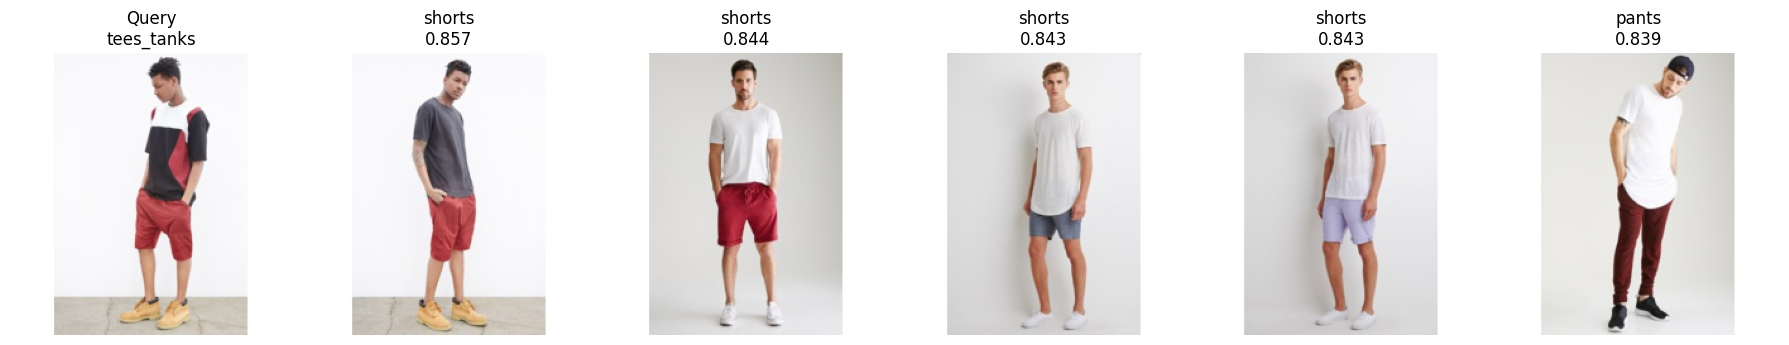

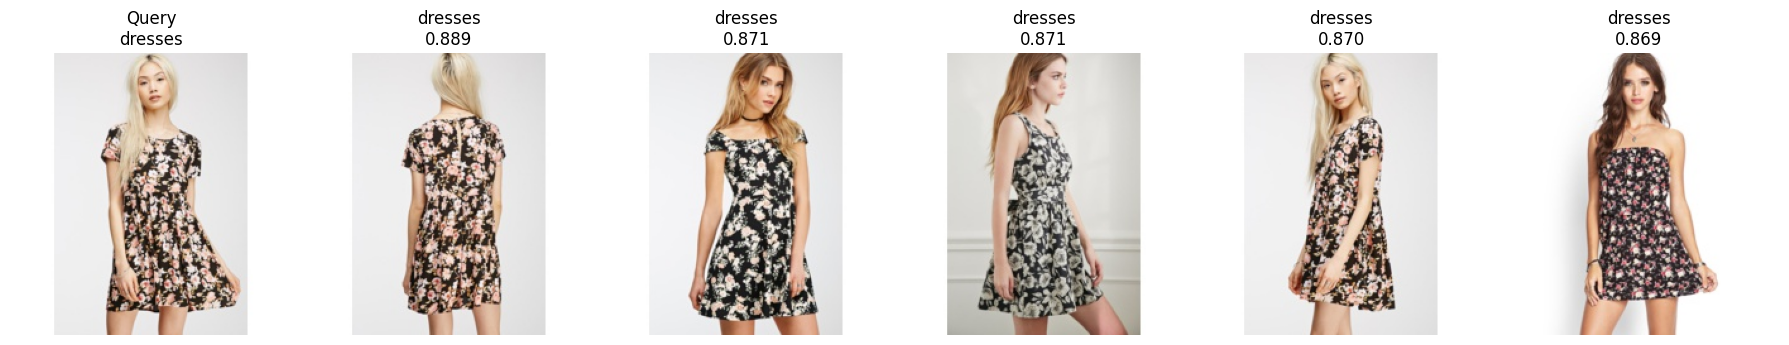

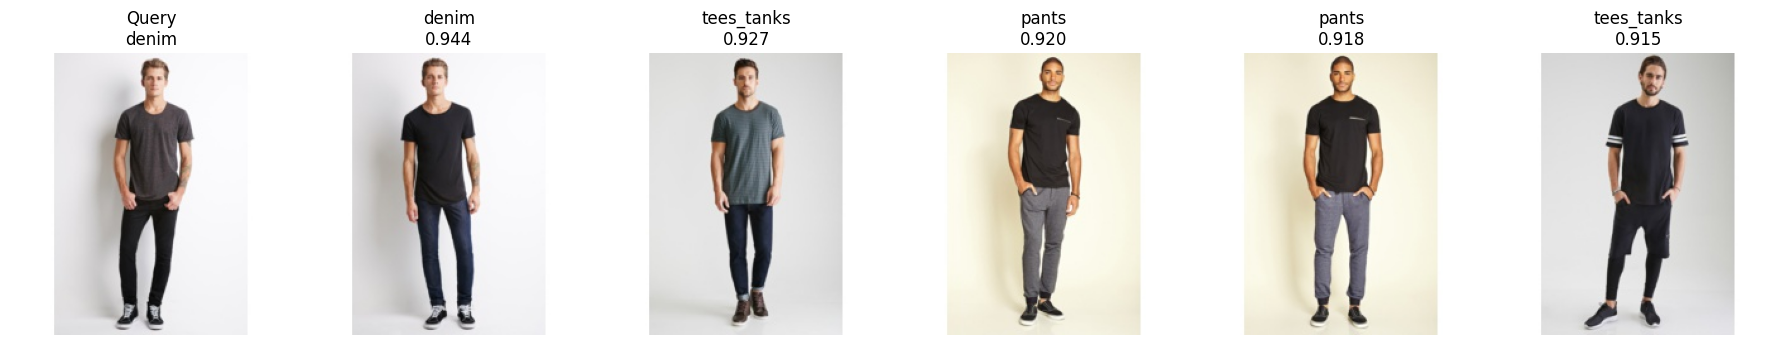

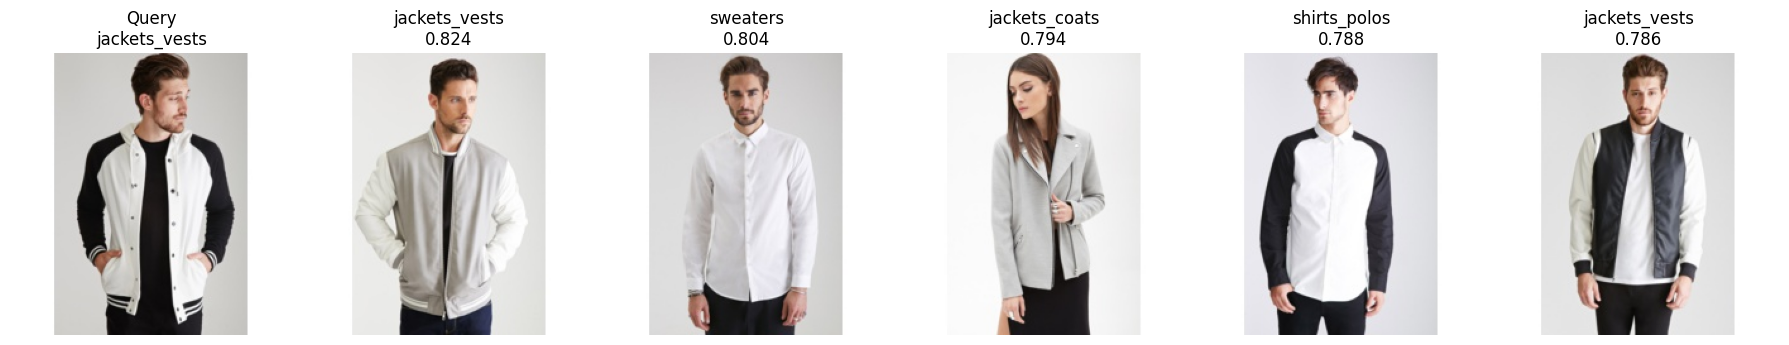

In [24]:
show_neighbors(tee_idx, meta, emb, image_col="processed_image_path", top_k=5)
show_neighbors(dress_idx, meta, emb, image_col="processed_image_path", top_k=5)
show_neighbors(denim_idx, meta, emb, image_col="processed_image_path", top_k=5)
show_neighbors(jacket_idx, meta, emb, image_col="processed_image_path", top_k=5)